In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Loan_Approval.csv")
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
df.columns = df.columns.str.strip()
df.columns


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [3]:
target = [col for col in df.columns if "loan" in col.lower() and "status" in col.lower()]
print("Target column:", target)


Target column: ['loan_status']


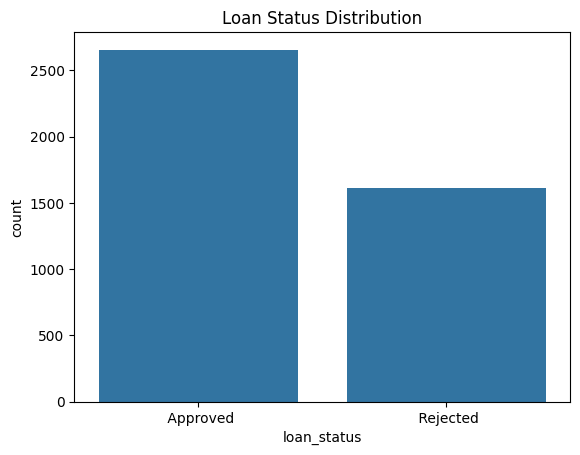

In [4]:
sns.countplot(x=df["loan_status"])
plt.title("Loan Status Distribution")
plt.show()


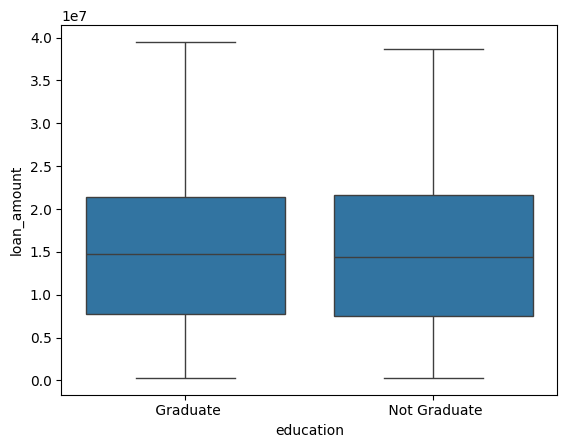

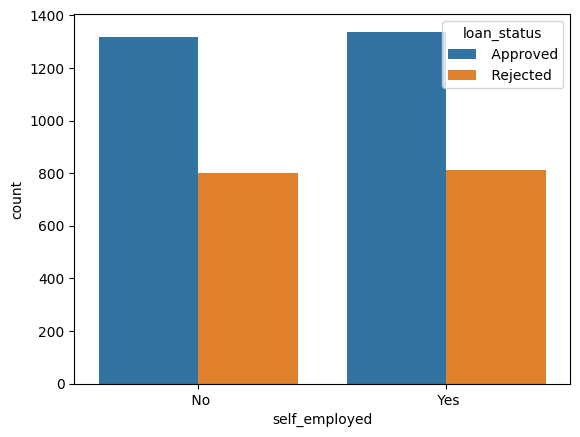

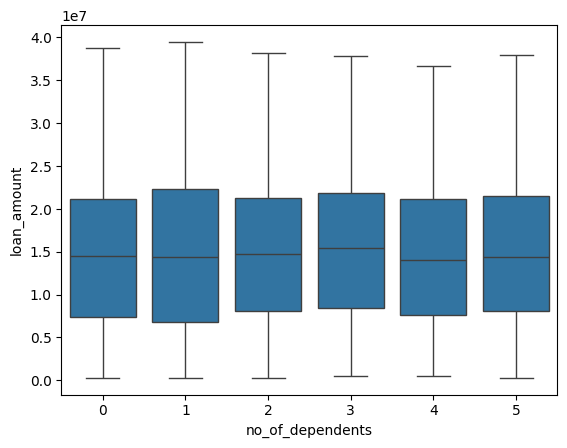

In [5]:
sns.boxplot(x="education", y="loan_amount", data=df)
plt.show()

sns.countplot(x="self_employed", hue="loan_status", data=df)
plt.show()

sns.boxplot(x="no_of_dependents", y="loan_amount", data=df)
plt.show()


In [6]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
df["loan_status"] = label.fit_transform(df["loan_status"])

df = pd.get_dummies(df, drop_first=True)
df.head()


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,False,False
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,True,True
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,False,False
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,False,False
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,True,True


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9789227166276346
[[529   7]
 [ 11 307]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [11]:
import pickle
pickle.dump(model, open("loan_model.pkl", "wb"))
print("Model saved successfully")


Model saved successfully
